# Research: Funding Rate Snipe Project

This notebook will do research about the existence of an edge with crypto funding rates of perpetual futures contracts (perps).

# Exchange

For this project we will use the crypto currency exchange Bitget. Bitget offers small trading fees, while being a large, trustworthy platform.
| Exchange | Spot maker | Spot taker | Perpetual maker | Perpetual taker | Notes |
| --- | ---: | ---: | ---: | ---: | --- |
| Binance | 0.10% | 0.10% | 0.02% | 0.05% | Large liquidity, widely used |
| Bitget | 0.10% | 0.10% | 0.02% | 0.06% | Often competitive for perpetual futures |
| Bybit | 0.10% | 0.10% | 0.02% | 0.055% | Strong perpetuals focus |
| OKX | 0.08% | 0.10% | 0.02% | 0.05% | Competitive fees, broad market |
| Coinbase Advanced | 0.40% | 0.60% | N/A | N/A | Higher retail fees, lower crypto focus |

The fees suggest, that all of the first 4 exchanges could be picked. To further investigate, we will look into a coin that paid out a funding rate around $\pm 1$ and check the trading volume. That is important as a large trading volume will allow us to execute large positions without changing the funding rate nor the contract price.

**STORJUSDT on 24.08.2026 at 22:00**
| Exchange | last funding rate | 24h trading volume |
| --- | ---: | ---: |
| Binance | -1.0986% | 60.965172 Mio $ | 
| Bitget | -1.0862% | 60.562908 Mio $ | 
| Bybit | **different payout time** | **arbitrage opportunity?** | 
| OKX | coin not available | - | 

As fees, funding rates and trading volumes are very similar for BitGet and Binance we can pick any of these two and will proceed with **BitGet**.

# Historical Funding Rate Payouts Analysis: Potential Payoff, Fees, Volume, Spread, Market Movement
For this we will fetch the relevant data of a few different coins with relevant funding rates from Bitget and analyze the data.

- ACEUSDT
- HOMEUSDT
- BICOUSDT

1. Data fetch using Bitget API

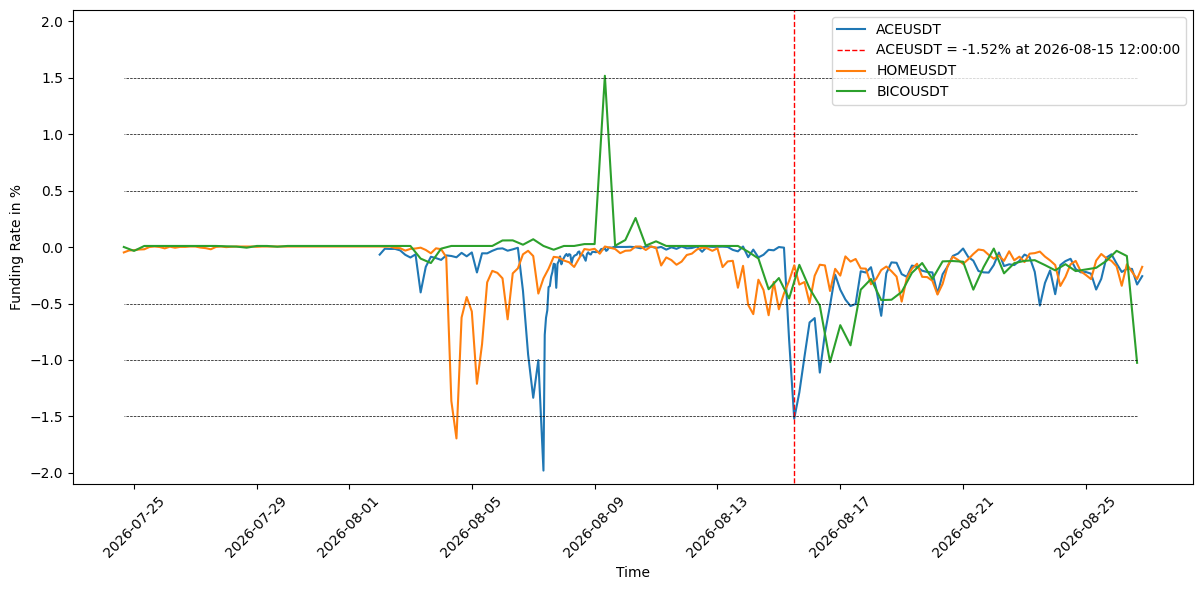

In [43]:
import requests
import numpy as np
from datetime import datetime, timezone
import matplotlib.pyplot as plt

url = 'https://api.bitget.com/api/v2/mix/market/history-fund-rate'

symbols = ['ACEUSDT', 'HOMEUSDT', 'BICOUSDT']
historical_rates_all = {}
plt.figure(figsize=(12, 6))

for symbol in symbols:
    response = requests.get(
        url,
        params={
            'symbol': symbol,
            'productType': 'USDT-FUTURES',
            'pageSize': 100,
            'pageNo': 1
        }
    )

    historical_rates = response.json().get('data', [])

    timestamps = np.array([datetime.fromtimestamp(int(entry['fundingTime']) / 1000,
    tz=timezone.utc) for entry in historical_rates])
    rates = np.array([float(entry['fundingRate']) for entry in historical_rates])

    period = int(abs((int(historical_rates[1]['fundingTime']) - int(historical_rates[0]['fundingTime'])))/1000/60/60)
    if period == 4:
        response_ = requests.get(
                url,
                params={
                    'symbol': symbol,
                    'productType': 'USDT-FUTURES',
                    'pageSize': 100,
                    'pageNo': 2
                }
            )
        timestamps_ = np.array([datetime.fromtimestamp(int(entry['fundingTime']) / 1000,
        tz=timezone.utc) for entry in response_.json().get('data', [])])
        rates_ = np.array([float(entry['fundingRate']) for entry in response_.json().get('data', [])])
        timestamps = np.concatenate((timestamps, timestamps_))
        rates = np.concatenate((rates, rates_))
        

    historical_rates_all[symbol] = {
        'timestamps': timestamps,
        'rates': rates
    }

    plt.plot(timestamps, np.array(rates)*100, label=symbol)
    plt.xlabel('Time')
    plt.ylabel('Funding Rate in %')
    plt.xticks(rotation=45)
    plt.tight_layout()

    if symbol == 'ACEUSDT':
        args = np.argwhere(abs(np.array(rates)) >= 0.015).flatten()
        # plt.scatter(timestamps[args], np.array(rates)[args]*100, color='red', s=10, label=f'{symbol} > 1.5%')
        plt.vlines([timestamps[args[0]]], -3, 3, color='red', linewidth=1, linestyle='--', label=f'{symbol} = {np.array(rates)[args[0]]*100:.2f}% at {timestamps[args[0]].strftime("%Y-%m-%d %H:%M:%S")}')

plt.ylim(-2.1, 2.1)
plt.hlines([1.5, 1., 0.5, -0.5, -1., -1.5], timestamps[0], timestamps[-1], color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.show()


To be able to say something about a potential profit for a certain funding rate $f$, extreme events for $|f|>\varepsilon$ need to be investigated further regarding:
- $f$ $\rightarrow$ potential relative profit
- perp price movement $\rightarrow$ directional risk
- perp trading volume $\rightarrow$ spread and price distortion risk

The funding rate $f=-1.52 \%$ spike of ACEUSDT at 2026-08-15 12:00:00 is investigated, regarding its spot and perp data.

Futures history-candles failed for ACEUSDT: 400 Client Error: Bad Request for url: https://api.bitget.com/api/v2/mix/market/history-candles?symbol=ACEUSDT&granularity=1m&startTime=1786794600000&endTime=1786795800000&limit=1000&productType=USDT-FUTURES


,timestamp,open,high,low,close,base_volume,quote_volume
0,2026-08-15 11:51:00+00:00,0.20507,0.20699,0.20405,0.20660,1620.35,333.474072
1,2026-08-15 11:52:00+00:00,0.20660,0.20802,0.20660,0.20702,19589.86,4056.773065
2,2026-08-15 11:53:00+00:00,0.20702,0.20702,0.20495,0.20692,10527.97,2162.455195
3,2026-08-15 11:54:00+00:00,0.20692,0.20786,0.20611,0.20758,6664.77,1380.568247
4,2026-08-15 11:55:00+00:00,0.20758,0.20758,0.20528,0.20528,2312.87,476.591454
5,2026-08-15 11:56:00+00:00,0.20528,0.20638,0.20461,0.20548,27902.08,5726.526522
6,2026-08-15 11:57:00+00:00,0.20548,0.20574,0.20400,0.20554,17742.97,3626.566933
7,2026-08-15 11:58:00+00:00,0.20554,0.20557,0.20400,0.20400,11683.01,2392.687498
8,2026-08-15 11:59:00+00:00,0.20400,0.20504,0.20226,0.20385,21998.26,4471.371173
9,2026-08-15 12:00:00+00:00,0.20385,0.20385,0.19978,0.20079,104975.43,21114.930704


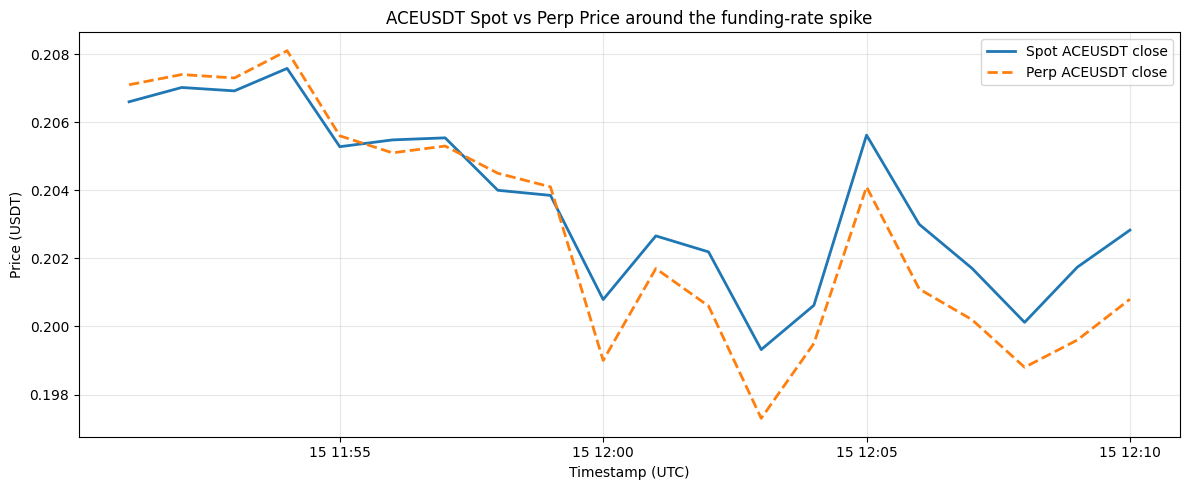

In [52]:
import pandas as pd


start_time = datetime(2026, 8, 15, 11, 50, tzinfo=timezone.utc)
end_time = datetime(2026, 8, 15, 12, 10, tzinfo=timezone.utc)

start_ms = int(start_time.timestamp() * 1000)
end_ms = int(end_time.timestamp() * 1000)

candle_columns = [
    'timestamp', 'open', 'high', 'low', 'close',
    'base_volume', 'quote_volume'
]

def fetch_candles(endpoint, extra_params=None):
    params = {
        'symbol': 'ACEUSDT',
        'granularity': '1m',
        'startTime': start_ms,
        'endTime': end_ms,
        'limit': 1000,
        **(extra_params or {})
    }

    response = requests.get(endpoint, params=params)
    response.raise_for_status()

    payload = response.json()
    if payload.get('code') != '00000':
        raise RuntimeError(payload)

    rows = payload.get('data', [])
    df = pd.DataFrame(rows)

    if df.empty:
        return df

    df = df.iloc[:, :len(candle_columns)]
    df.columns = candle_columns[:df.shape[1]]
    df['timestamp'] = pd.to_datetime(
        pd.to_numeric(df['timestamp']), unit='ms', utc=True
    )

    numeric_columns = [c for c in df.columns if c != 'timestamp']
    df[numeric_columns] = df[numeric_columns].apply(
        pd.to_numeric, errors='coerce'
    )

    return df.sort_values('timestamp').reset_index(drop=True)


# Bitget sometimes rejects certain spot history-candles requests for small-cap symbols.
# Retry with the non-history endpoint as a fallback and normalize the DataFrame.
try:
    spot_candles = fetch_candles(
        'https://api.bitget.com/api/v2/spot/market/candles',
        {'granularity': '1min'}
    )
except Exception as e:
    print(f"Spot history-candles failed for ACEUSDT: {e}")

    resp = requests.get(
        'https://api.bitget.com/api/v2/spot/market/candles',
        params={
            'symbol': 'ACEUSDT',
            'granularity': '1m',
            'startTime': start_ms,
            'endTime': end_ms,
            'limit': 1000
        },
        timeout=20
    )
    resp.raise_for_status()

    payload = resp.json()
    if payload.get('code') != '00000':
        raise RuntimeError(f"Bitget spot candles API error: {payload}")

    rows = payload.get('data', [])
    spot_candles = pd.DataFrame(rows)

    if not spot_candles.empty:
        spot_candles = spot_candles.iloc[:, :len(candle_columns)]
        spot_candles.columns = candle_columns[:spot_candles.shape[1]]
        spot_candles['timestamp'] = pd.to_datetime(
            pd.to_numeric(spot_candles['timestamp']), unit='ms', utc=True
        )

        numeric_columns = [c for c in spot_candles.columns if c != 'timestamp']
        spot_candles[numeric_columns] = spot_candles[numeric_columns].apply(
            pd.to_numeric, errors='coerce'
        )
        spot_candles = spot_candles.sort_values('timestamp').reset_index(drop=True)

try:
    futures_candles = fetch_candles(
        'https://api.bitget.com/api/v2/mix/market/history-candles',
        {'productType': 'USDT-FUTURES'}
    )
except Exception as e:
    print(f"Futures history-candles failed for ACEUSDT: {e}")

    resp = requests.get(
        'https://api.bitget.com/api/v2/mix/market/candles',
        params={
            'symbol': 'ACEUSDT',
            'granularity': '1m',
            'startTime': start_ms,
            'endTime': end_ms,
            'limit': 1000,
            'productType': 'USDT-FUTURES'
        },
        timeout=20
    )
    resp.raise_for_status()

    payload = resp.json()
    if payload.get('code') != '00000':
        raise RuntimeError(f"Bitget futures candles API error: {payload}")

    rows = payload.get('data', [])
    futures_candles = pd.DataFrame(rows)

    if not futures_candles.empty:
        futures_candles = futures_candles.iloc[:, :len(candle_columns)]
        futures_candles.columns = candle_columns[:futures_candles.shape[1]]
        futures_candles['timestamp'] = pd.to_datetime(
            pd.to_numeric(futures_candles['timestamp']), unit='ms', utc=True
        )

        numeric_columns = [c for c in futures_candles.columns if c != 'timestamp']
        futures_candles[numeric_columns] = futures_candles[numeric_columns].apply(
            pd.to_numeric, errors='coerce'
        )

        futures_candles = futures_candles[
            (futures_candles['timestamp'] >= start_time) &
            (futures_candles['timestamp'] <= end_time)
        ].sort_values('timestamp').reset_index(drop=True)

display(spot_candles)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    spot_candles['timestamp'],
    spot_candles['close'],
    label='Spot ACEUSDT close',
    linewidth=2
)
ax.plot(
    futures_candles['timestamp'],
    futures_candles['close'],
    label='Perp ACEUSDT close',
    linestyle='--',
    linewidth=2
)

ax.set_title('ACEUSDT Spot vs Perp Price around the funding-rate spike')
ax.set_xlabel('Timestamp (UTC)')
ax.set_ylabel('Price (USDT)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()